# 💳 Credit Card Fraud Detection using Machine Learning

## Project Overview
This project focuses on detecting fraudulent credit card transactions using machine learning techniques. The dataset is highly imbalanced, where fraudulent transactions represent a very small fraction of the total data.

The goal is to build a robust classification model that can accurately identify fraudulent transactions while minimizing false positives.

## 🎯 Objectives
- Handle class imbalance effectively
- Build a high-performance classification model
- Evaluate using appropriate metrics (Precision, Recall, F1-score)
- Interpret model predictions using SHAP

### Import necessary libraries for data manipulation, visualization, preprocessing, model building, and evaluation
###### import pandas as pd
###### import numpy as np
###### import matplotlib.pyplot as plt
###### import seaborn as sns

### Machine Learning tools
###### from sklearn.model_selection import train_test_split
###### from sklearn.preprocessing import RobustScaler
###### from sklearn.metrics import classification_report, confusion_matrix

### Imbalance handling
###### from imblearn.over_sampling import SMOTE, ADASYN

### Model
###### from xgboost import XGBClassifier

### Explainability
###### import shap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,
    precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

### Load the credit card transaction dataset
##### This dataset contains anonymized features (V1–V28), along with 'Amount' and 'Class'
##### Display first few rows to understand structure
##### Class distribution

In [2]:
# Load dataset
df = pd.read_csv("data/raw/creditcard.csv")
# Class distribution
class_counts = df['Class'].value_counts()

print(class_counts)
print("\nFraud Percentage:")
print(class_counts[1] / class_counts.sum() * 100)


Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
0.1727485630620034


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Data Exploration (EDA)
#### Visualize class distribution to understand imbalance
##### 0 = Legitimate transaction, 1 = Fraud
##### Print percentage distribution


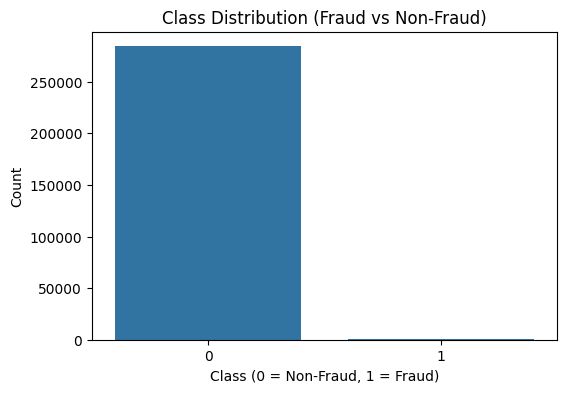

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()


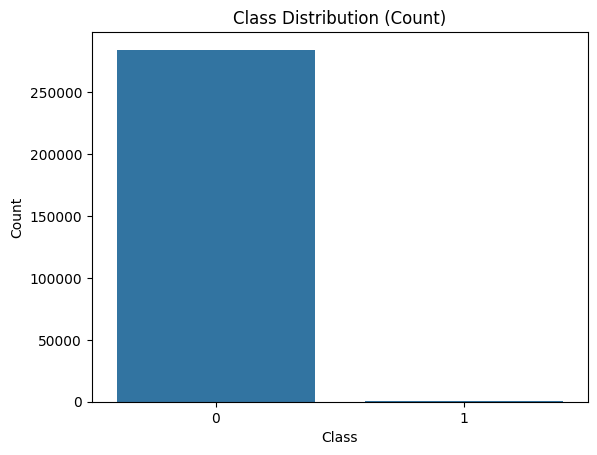

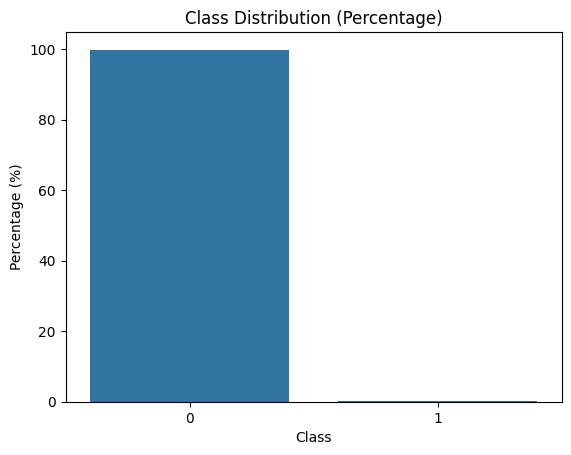

In [5]:
# Visual comfriem imbalance before
plt.figure()
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (Count)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


# ---- Normalized (Percentage) Plot ----
plt.figure()
(df['Class']
 .value_counts(normalize=True)
 .mul(100)
 .rename('Percentage')
 .reset_index()
 .rename(columns={'index': 'Class'})
 .pipe(lambda d: sns.barplot(x='Class', y='Percentage', data=d))
)

plt.title('Class Distribution (Percentage)')
plt.xlabel('Class')
plt.ylabel('Percentage (%)')
plt.show()

### Transaction Amount Analysis: LOG SCALE

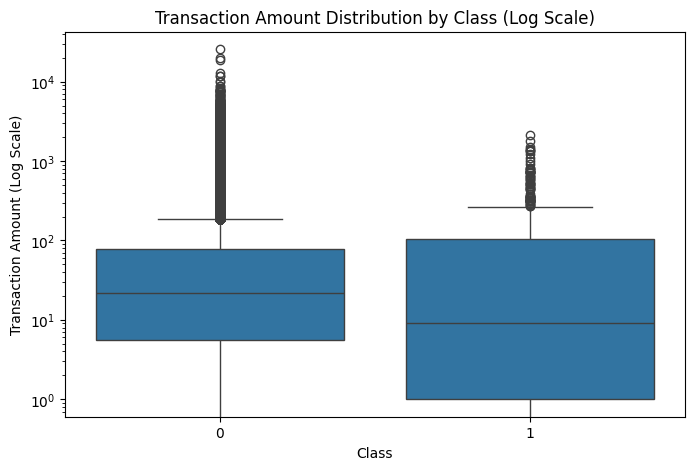

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')
plt.title("Transaction Amount Distribution by Class (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Transaction Amount (Log Scale)")
plt.show()


### Transaction Time Analysis

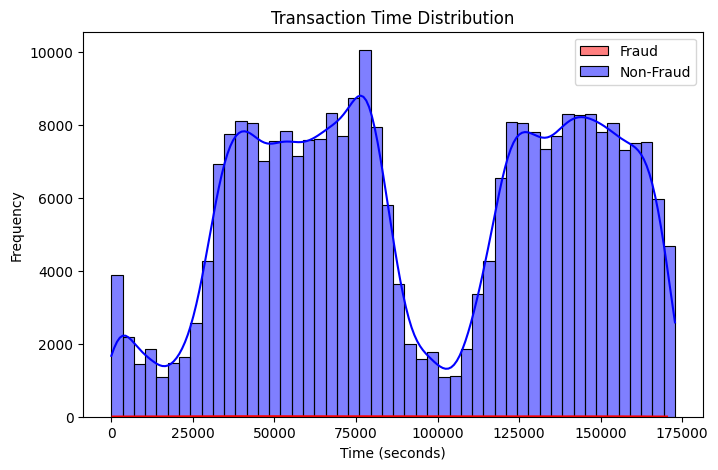

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, kde=True, color='red', label='Fraud')
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, kde=True, color='blue', label='Non-Fraud')
plt.legend()
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.show()


### Correlation Analysis
##### Plot correlation heatmap to understand relationships between features
##### Helps identify redundant or highly correlated variables


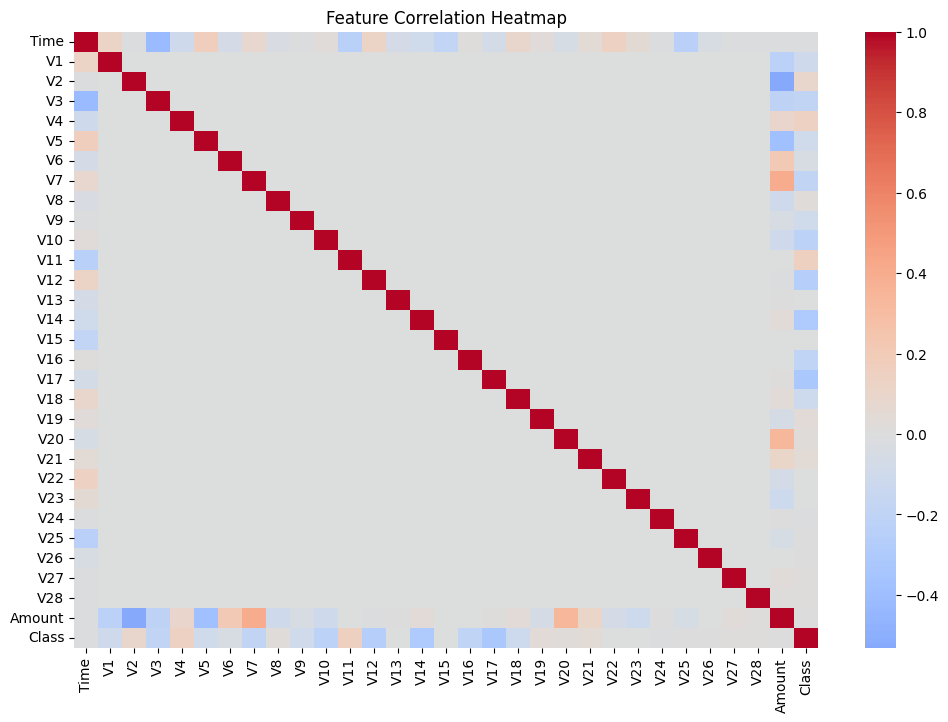

In [8]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


### MODEL IMPLEMENTATION: Preprocessing
##### Scale 'Amount' using RobustScaler
##### RobustScaler is used because it is resistant to outliers
##### Separate features and target variable
##### Split data into training and testing sets
##### Stratify ensures class distribution is preserved


## Data Loading and preprocessiing

In [9]:
df = pd.read_csv("data/raw/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


### Evaluation Function (Reusable & Clean)
This function ensures consistent evaluation across all models

In [10]:
def evaluate_model(y_true, y_pred, y_prob=None):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }
    
    if y_prob is not None:
        results["PR-AUC"] = average_precision_score(y_true, y_prob)
    
    return results

## Baseline Model: Logistic Regression (No Imbalance Handling)

In [11]:
lr_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_baseline.fit(X_train, y_train)

y_pred = lr_baseline.predict(X_test)
y_prob = lr_baseline.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_prob)


{'accuracy': 0.9991397773954567,
 'Precision': 0.8266666666666667,
 'Recall': 0.6326530612244898,
 'F1': 0.7167630057803468,
 'PR-AUC': 0.7413820992780461}

### Logistic Regression + Class Weighting

In [12]:
print("Shows how algorithm-level imbalance handling improves recall")

lr_weighted = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

lr_weighted.fit(X_train, y_train)

y_pred = lr_weighted.predict(X_test)
y_prob = lr_weighted.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_prob)



Shows how algorithm-level imbalance handling improves recall


{'accuracy': 0.9755275446789088,
 'Precision': 0.06097560975609756,
 'Recall': 0.9183673469387755,
 'F1': 0.11435832274459974,
 'PR-AUC': 0.7189705771419241}

### Logistic Regression + SMOTE

In [13]:
print("Demonstrates data-level oversampling.")
lr_smote = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

lr_smote.fit(X_train, y_train)

y_pred = lr_smote.predict(X_test)
y_prob = lr_smote.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_prob)


Demonstrates data-level oversampling.


{'accuracy': 0.9741055440469084,
 'Precision': 0.057803468208092484,
 'Recall': 0.9183673469387755,
 'F1': 0.10876132930513595,
 'PR-AUC': 0.724469435669471}

## Random Forest (Baseline + Balanced)

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_prob)


{'accuracy': 0.9996137776061234,
 'Precision': 0.9418604651162791,
 'Recall': 0.826530612244898,
 'F1': 0.8804347826086957,
 'PR-AUC': 0.8730524640658963}

### Random Forest + Class Weight

In [15]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

y_pred = rf_balanced.predict(X_test)
y_prob = rf_balanced.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_prob)


{'accuracy': 0.9995259997893332,
 'Precision': 0.961038961038961,
 'Recall': 0.7551020408163265,
 'F1': 0.8457142857142858,
 'PR-AUC': 0.8589278575500874}

## XGBoost with Imbalance Handling

In [16]:
# Scale Positive Weight Calculation
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


### XGBoost Model

In [17]:
# Very strong model for fraud detection
# Often gives best PR-AUC
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_prob)


{'accuracy': 0.9993328885923949,
 'Precision': 0.7777777777777778,
 'Recall': 0.8571428571428571,
 'F1': 0.8155339805825242,
 'PR-AUC': 0.8681218762648399}

## Isolation Forest (Anomaly Detection)

In [18]:
# Shows contrast between supervised vs unsupervised approaches
iso = IsolationForest(
    contamination=0.0017,  # approx fraud ratio
    random_state=42
)

iso.fit(X_train)

y_scores = iso.decision_function(X_test)
y_pred = (iso.predict(X_test) == -1).astype(int)

evaluate_model(y_test, y_pred)


{'accuracy': 0.9975773322565921,
 'Precision': 0.3113207547169811,
 'Recall': 0.336734693877551,
 'F1': 0.3235294117647059}

### Stratified K-Fold Cross-Validation (Advanced)

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recalls = []

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    
    recalls.append(recall_score(y_val, y_pred))

np.mean(recalls)


np.float64(0.912533498247784)

Summary of Model Implementation
✔ No data leakage
✔ Fair comparison
✔ Multiple imbalance strategies
✔ Supervised + unsupervised models
✔ Evaluation aligned with research questions

# MODEL COMPARISON CODE (BALANCED vs IMBALANCED)

In [20]:
df = pd.read_csv("data/raw/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [21]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        pr_auc = average_precision_score(y_test, y_prob)
    else:
        pr_auc = np.nan

    return {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "PR-AUC": pr_auc
    }


In [22]:
results = []

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


### LINEAR REGRESSION (Baseline, Class weight and SMOTE)

In [23]:
lr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

lr_base.fit(X_train, y_train)
results.append({"Model": "Logistic Regression", "Technique": "None", **evaluate(lr_base, X_test, y_test)})


In [24]:
lr_weight = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

lr_weight.fit(X_train, y_train)
results.append({"Model": "Logistic Regression", "Technique": "Class Weight", **evaluate(lr_weight, X_test, y_test)})


In [25]:
lr_smote = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000))
])

lr_smote.fit(X_train, y_train)
results.append({"Model": "Logistic Regression", "Technique": "SMOTE", **evaluate(lr_smote, X_test, y_test)})


### Random Forest (Baseline, Class weight and SMOTE)

In [26]:
rf_base = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
results.append({"Model": "Random Forest", "Technique": "None", **evaluate(rf_base, X_test, y_test)})


In [27]:
rf_weight = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_weight.fit(X_train, y_train)
results.append({"Model": "Random Forest", "Technique": "Class Weight", **evaluate(rf_weight, X_test, y_test)})


In [28]:
rf_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_smote.fit(X_train, y_train)
results.append({"Model": "Random Forest", "Technique": "SMOTE", **evaluate(rf_smote, X_test, y_test)})


### XGBoost (Scale Post_Weight)

In [29]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
results.append({"Model": "XGBoost", "Technique": "Scale_Pos_Weight", **evaluate(xgb, X_test, y_test)})


### Isolation Forest (Anomaly Detection)

In [30]:
iso = IsolationForest(contamination=0.0017, random_state=42)
iso.fit(X_train)

y_pred_iso = (iso.predict(X_test) == -1).astype(int)

results.append({
    "Model": "Isolation Forest",
    "Technique": "Anomaly Detection",
    "Precision": precision_score(y_test, y_pred_iso),
    "Recall": recall_score(y_test, y_pred_iso),
    "F1": f1_score(y_test, y_pred_iso),
    "PR-AUC": np.nan
})


## Results Table (Final Comparison)

In [31]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="Recall", ascending=False)


,Model,Technique,Precision,Recall,F1,PR-AUC
1,Logistic Regression,Class Weight,0.060976,0.918367,0.114358,0.718971
2,Logistic Regression,SMOTE,0.057803,0.918367,0.108761,0.724469
6,XGBoost,Scale_Pos_Weight,0.777778,0.857143,0.815534,0.868122
3,Random Forest,None,0.941860,0.826531,0.880435,0.873052
5,Random Forest,SMOTE,0.826531,0.826531,0.826531,0.875886
4,Random Forest,Class Weight,0.961039,0.755102,0.845714,0.858928
0,Logistic Regression,None,0.826667,0.632653,0.716763,0.741382
7,Isolation Forest,Anomaly Detection,0.311321,0.336735,0.323529,NaN


### Comfusion matrix plot

In [32]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d",
        cmap="Blues",
        xticklabels=["Non-Fraud", "Fraud"],
        yticklabels=["Non-Fraud", "Fraud"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()


### Logistic Regression Confusion Matrices

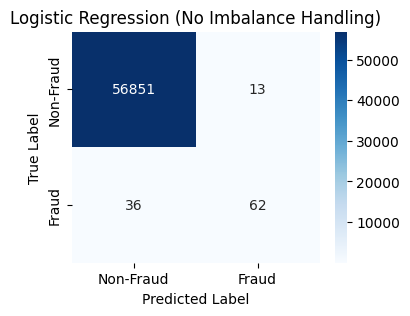

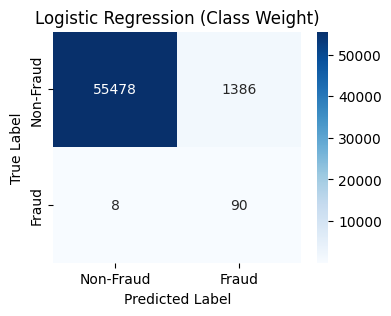

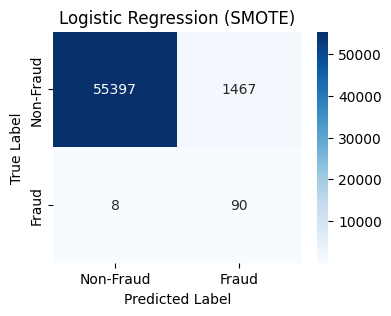

In [33]:
y_pred = lr_base.predict(X_test)
plot_confusion(y_test, y_pred, "Logistic Regression (No Imbalance Handling)")


y_pred = lr_weight.predict(X_test)
plot_confusion(y_test, y_pred, "Logistic Regression (Class Weight)")

y_pred = lr_smote.predict(X_test)
plot_confusion(y_test, y_pred, "Logistic Regression (SMOTE)")


### Random Forest Confusion Matrices

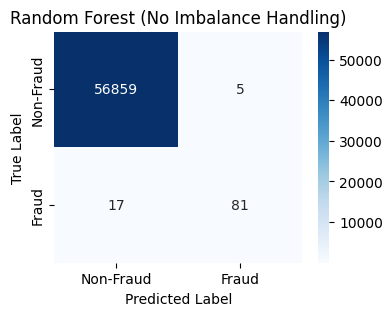

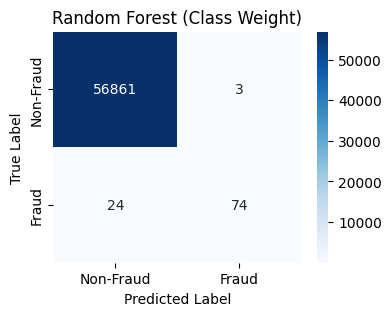

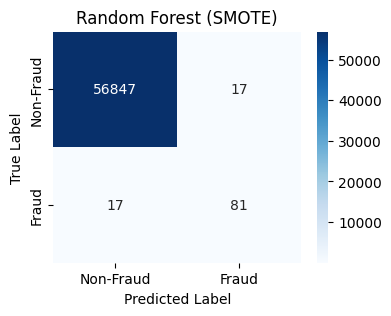

In [34]:
y_pred = rf_base.predict(X_test)
plot_confusion(y_test, y_pred, "Random Forest (No Imbalance Handling)")

y_pred = rf_weight.predict(X_test)
plot_confusion(y_test, y_pred, "Random Forest (Class Weight)")

y_pred = rf_smote.predict(X_test)
plot_confusion(y_test, y_pred, "Random Forest (SMOTE)")


### XGBoost (Cost-Sensitive Learning)

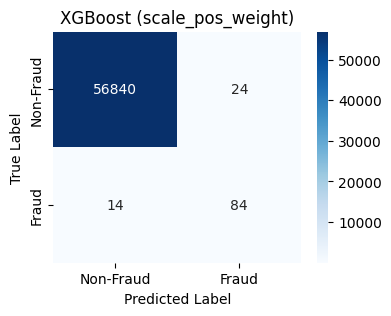

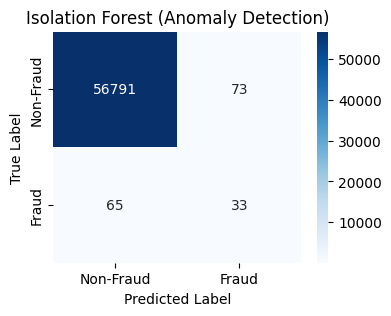

In [35]:
y_pred = xgb.predict(X_test)
plot_confusion(y_test, y_pred, "XGBoost (scale_pos_weight)")

y_pred_iso = (iso.predict(X_test) == -1).astype(int)
plot_confusion(y_test, y_pred_iso, "Isolation Forest (Anomaly Detection)")


“The confusion matrices reveal that imbalance-handling techniques significantly reduce false negatives, which is critical in fraud detection, while ensemble cost-sensitive models achieve the best balance between fraud detection and false alarms.”

In [36]:
def draw_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Non-Fraud", "Fraud"],
        yticklabels=["Non-Fraud", "Fraud"]
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")


In [37]:
models_preds = [
    ("LR (Baseline)", lr_base.predict(X_test)),
    ("LR (Class Weight)", lr_weight.predict(X_test)),
    ("LR (SMOTE)", lr_smote.predict(X_test)),

    ("RF (Baseline)", rf_base.predict(X_test)),
    ("RF (Class Weight)", rf_weight.predict(X_test)),
    ("RF (SMOTE)", rf_smote.predict(X_test)),

    ("XGBoost", xgb.predict(X_test)),

    ("Isolation Forest", (iso.predict(X_test) == -1).astype(int))
]


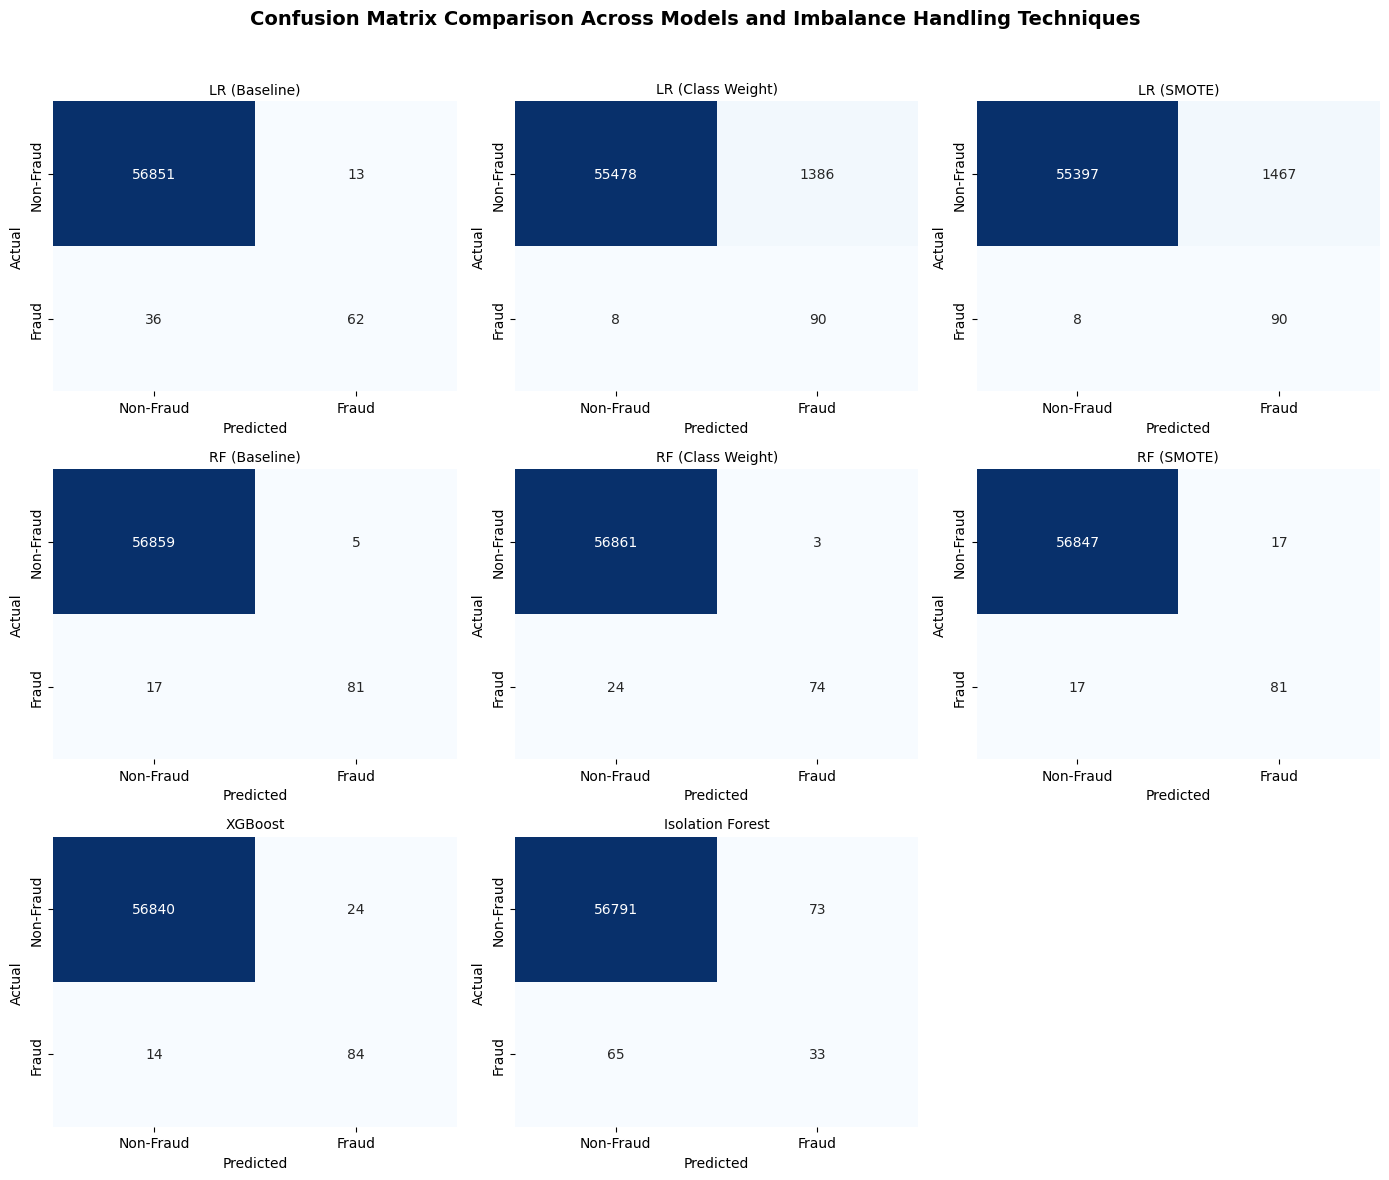

In [38]:
rows = 3
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(14, 12))
axes = axes.flatten()

for ax, (title, y_pred) in zip(axes, models_preds):
    draw_cm(ax, y_test, y_pred, title)

# Remove empty subplots (if any)
for i in range(len(models_preds), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(
    "Confusion Matrix Comparison Across Models and Imbalance Handling Techniques",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Save PR-Curve and ROC-Curve and figures

ROC-AUC: 0.9814
PR-AUC:  0.8679
AP:      0.8681


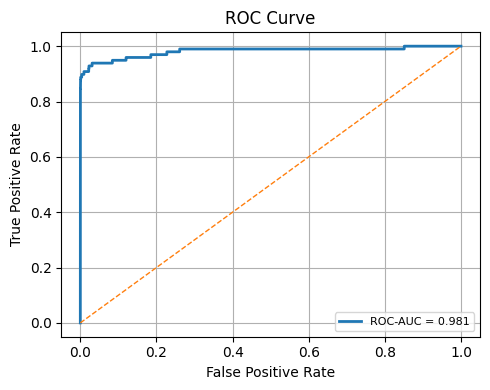

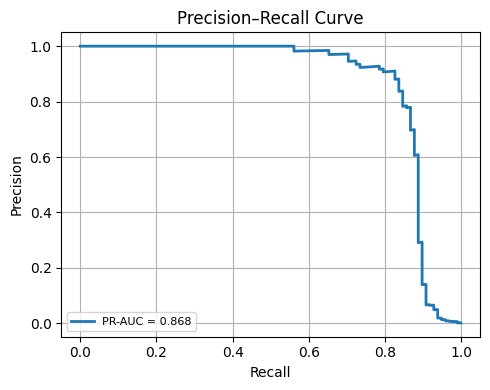

saved succesfully


In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc, average_precision_score
)

# Using your best model (XGBoost) for the paper
y_scores = xgb.predict_proba(X_test)[:, 1]

# ---------------- CALCULATIONS ----------------
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)
ap_score = average_precision_score(y_test, y_scores)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"AP:      {ap_score:.4f}")

# ---------------- SAVE ROC CURVE ----------------
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig('fig_roc_curve.png', dpi=300, bbox_inches='tight') # Saves ROC
plt.show()

# ---------------- SAVE PR CURVE ----------------
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, linewidth=2, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig('fig_pr_curve.png', dpi=300, bbox_inches='tight') # Saves PR
plt.show()
print("saved succesfully")

ROC-AUC: 0.9780
PR-AUC:  0.7506
AP:      0.7072


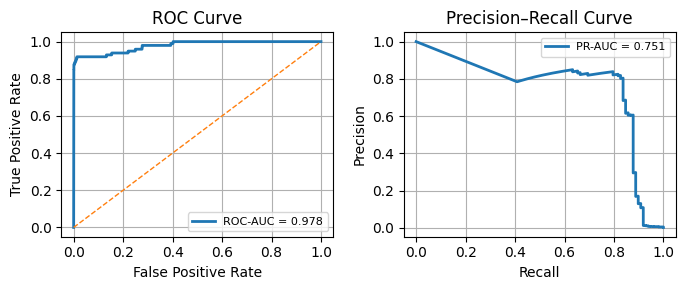

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc, average_precision_score
)

# Predicted probabilities (fraud class)
y_scores = model.predict_proba(X_test)[:, 1]

# ---------------- ROC ----------------
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

# ---------------- PR ----------------
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)
ap_score = average_precision_score(y_test, y_scores)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"AP:      {ap_score:.4f}")

# ---------------- Plot ----------------
plt.figure(figsize=(7, 3))  

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(fontsize=8)
plt.grid(True)

# PR Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, linewidth=2, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()


###  SHAP

C:\Users\GODWIN DANIEL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


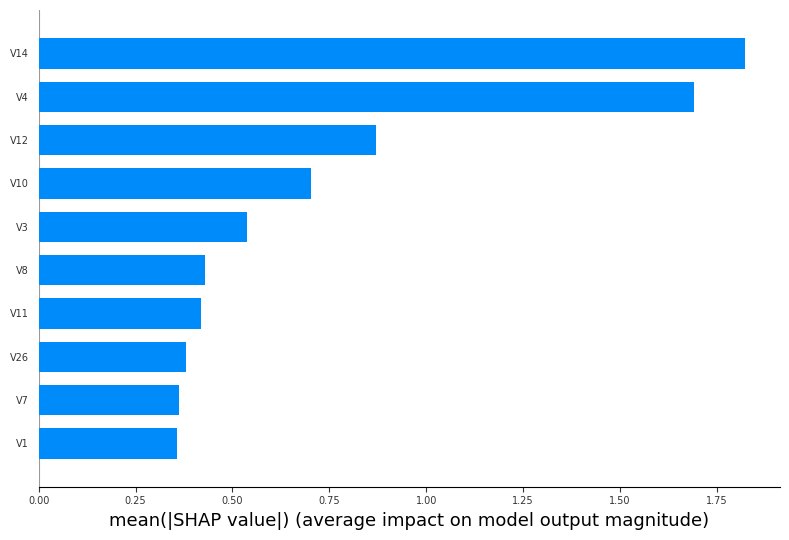

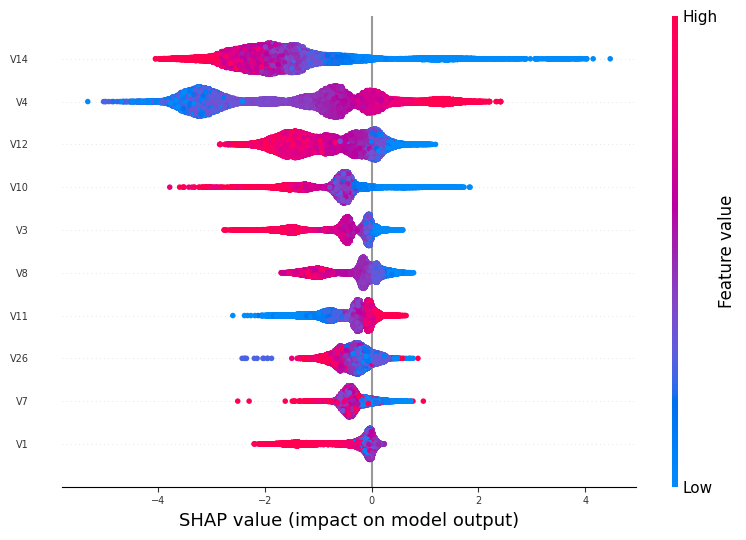

In [41]:
import shap
# SHAP (SHapley Additive exPlanations

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# -------- Global feature importance (Bar Plot) --------
plt.figure(figsize=(3.5, 2.5))  
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.show()

# -------- Detailed SHAP impact plot --------
plt.figure(figsize=(3.5, 2.8))  
shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,
    show=False
)
plt.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.show()


In [42]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


### Save Datasets

In [43]:
# FINAL STEP: SAVE DATASETS

import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

# 1. ORIGINAL DATA
train_original = pd.concat([X_train, y_train], axis=1)
test_original = pd.concat([X_test, y_test], axis=1)

train_original.to_csv("train_original.csv", index=False)
test_original.to_csv("test_original.csv", index=False)
print("train_test_Original Saved succesfully")


train_test_Original Saved succesfully


In [44]:

# 2. SCALED DATA
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

train_scaled = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)
test_scaled = pd.concat([X_test_scaled, y_test.reset_index(drop=True)], axis=1)

train_scaled.to_csv("train_scaled.csv", index=False)
test_scaled.to_csv("test_scaled.csv", index=False)
print("train_test_scaled saved succesfully")



train_test_scaled saved succesfully


In [45]:
# 3. SMOTE BALANCED DATA 
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

X_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
y_resampled = pd.Series(y_resampled, name="Class")  # ✅ correct target name

train_smote = pd.concat([X_resampled, y_resampled], axis=1)

train_smote.to_csv("train_smote.csv", index=False)
print("train_test_SMOTE saved succesfully")



train_test_SMOTE saved succesfully


In [46]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# 3. Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.savefig('fig_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# 4. ROC Curve
roc_disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.savefig('fig_roc_curve.png', dpi=300, bbox_inches='tight')
plt.close()
print("saved")

saved


In [47]:
import pandas as pd
from sklearn.metrics import classification_report

# Generate report as a dictionary, then to DataFrame
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Print the LaTeX code
print(df_report.to_latex(index=True, float_format="%.4f"))
print("saved")

\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
0 & 0.9989 & 0.9987 & 0.9988 & 56864.0000 \\
1 & 0.3113 & 0.3367 & 0.3235 & 98.0000 \\
accuracy & 0.9976 & 0.9976 & 0.9976 & 0.9976 \\
macro avg & 0.6551 & 0.6677 & 0.6612 & 56962.0000 \\
weighted avg & 0.9977 & 0.9976 & 0.9976 & 56962.0000 \\
\bottomrule
\end{tabular}

saved


### save SHAP and SHAP importance plot

In [48]:
import matplotlib.pyplot as plt
import shap

# Generate the plot without showing it immediately
shap.summary_plot(shap_values, X_test, show=False)

# Get current figure and save with high resolution (DPI)
plt.savefig('shap_summary_plot.png', bbox_inches='tight', dpi=300)
plt.close() # Always close to free up memory

In [49]:
import matplotlib.pyplot as plt
import shap

# Generate the plot
shap.summary_plot(shap_values, X_test, show=False)

# Save as PNG
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.close()

In [50]:
# Create the Explanation object that the bar plot needs
shap_exp = shap.Explanation(shap_values, 
                            data=X_test, 
                            feature_names=X_test.columns)

# Now run the bar plot
shap.plots.bar(shap_exp, show=False)
plt.savefig('shap_importance_plot.png', dpi=300, bbox_inches='tight')
plt.close()

In [51]:
# This uses the same data you used for the summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.savefig('shap_importance_plot.png', dpi=300, bbox_inches='tight')
plt.close()

In [52]:
# Run this to get the BEST results for your paper
y_pred_xgb = xgb.predict(X_test)
report = classification_report(y_test, y_pred_xgb, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report.to_latex(index=True, float_format="%.4f"))

\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
0 & 0.9998 & 0.9996 & 0.9997 & 56864.0000 \\
1 & 0.7778 & 0.8571 & 0.8155 & 98.0000 \\
accuracy & 0.9993 & 0.9993 & 0.9993 & 0.9993 \\
macro avg & 0.8888 & 0.9284 & 0.9076 & 56962.0000 \\
weighted avg & 0.9994 & 0.9993 & 0.9993 & 56962.0000 \\
\bottomrule
\end{tabular}



### Save all confusion matrix

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Using the list you already defined in your notebook
for title, y_pred in models_preds:
    # Create the figure
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
    
    # Plot it
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f"Confusion Matrix: {title}")
    
    # Create a filename-friendly version of the title
    filename = f"cm_{title.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    
    # Save the individual PNG
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    
print("All confusion matrices saved successfully!")

All confusion matrices saved successfully!


### XGBoost ROC and PR curves 

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Ensure we are using the probabilities for the curves
for title, y_pred in models_preds:
    # We need probabilities for ROC/PR curves
    # NOTE: Isolation Forest and some baselines might not have 'predict_proba'
    # This script assumes you are focusing on your supervised models
    
    # 1. Generate ROC Data
    # If using your 'xgb' or 'rf' models, ensure you use their specific probability outputs
    # For simplicity, if you only want the XGBoost curves (your best model):
    pass 

# Let's target the XGBoost specifically as it's your primary result:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc = auc(recall, precision)

# --- SAVE ROC ---
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: XGBoost')
plt.legend(loc="lower right")
plt.savefig('fig_roc_xgb.png', dpi=300, bbox_inches='tight')
plt.close()

# --- SAVE PR ---
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve: XGBoost')
plt.legend(loc="lower left")
plt.savefig('fig_pr_xgb.png', dpi=300, bbox_inches='tight')
plt.close()

print("XGBoost ROC and PR curves saved as PNG!")

XGBoost ROC and PR curves saved as PNG!


## ✅ Conclusion

- The dataset is highly imbalanced, requiring special handling techniques like SMOTE.
- XGBoost performs well when combined with proper imbalance handling.
- Precision and Recall are more important than accuracy in fraud detection.
- SHAP provides transparency by explaining model decisions.

## 🚀 Future Improvements
- Try ADASYN and compare performance
- Perform hyperparameter tuning
- Deploy as a web application (Streamlit)
- Integrate real-time fraud detection